# DECISION TREES
### Importing Python Libraries 
They are imported for data handling, visualization, machine learning, and evaluation:
-  `collections.Counter` to help compute the majority class in the custom decision tree implementation.
- `sklearn.datasets` to load the breast cancer dataset.
- `numpy` and `pandas` for numerical operations and data manipulation.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from collections import Counter


### Node class
The node class represents a single node in the decision tree. Each node can be either:
- An **internal node** that contains a decision rule (feature and threshold) and links to left and right child nodes.
- A **leaf node** that stores a predicted class label.

**Needed attributes:**
1. "feature_index" : of feature used to split this node
2. "threshold" : value of the feature threshold to decide branching 
3. "left_child" & "right_child" : pointers to left and right children depending on threshold
4. "label_value" : the predicted class label if node is a leaf, otherwise None

**Functions in class:**
- "is_leaf_node" returns true if there is a value in label_value meaning it's a leaf node

In [2]:
class Node:
    def __init__(self, feature_index=None, threshold=None, left_child=None, right_child=None, label_value=None):
        self.feature_index = feature_index
        self.threshold = threshold
        self.left_child = left_child
        self.right_child = right_child
        self.label_value = label_value
        
    def is_leaf_node(self):
        return self.label_value is not None

### Decision Tree Classifier Class:
This is a Python implementation of a decision tree classifier that builds a tree based on **information gain (IG)**. The classifier supports:

- `max_depth`: Maximum depth of the tree.
- `min_samples_split`: Minimum number of samples required to split a node.

1. Fit:
- It converts data to NumPy arrays
- It trains the decision tree on the part of the dataset labelled as training dataset 
- It builds the tree recursively using `build_tree()`

2. Entropy:
- The entropy measures how uncertain the predicition is depending on the features and labels given. 
- the `counts` is an array that has in counts[0] the count of occurences of  y = 0 (malignant) and in counts[1] the count of occurences of y = 1 (benign)
- the `probabilities` changes the 'counts' to probabilities by dividing on the total number of data given --> it also removes zeros to avoid log(0).
- the `entropy` is then calculated as negative sum of the probability of occurence of this label multiplied by its log

3. Information Gain:
- it quantifies the reduction in uncertainty (entropy) achieved by splitting the data based on a feature. A higher IG means the feature better separates the classes.  
Computation: 
- If a split does not divide the samples (all go to one child), IG = 0 because the split is useless.
- Compute the entropy of the parent node before splitting.
- Compute the entropy of the left and right child nodes after splitting using a candidate threshold.
- Weight the child entropies by the proportion of samples in each child:


4. Get Best Split:
- Loops over all features and candidate thresholds.
- Selects the split that maximizes information gain.

5. Build Decision Tree:
- Stops if node is pure or meets stopping criteria.
- Recursively splits data to build left and right child nodes.
- Updates feature_importances_ by adding the IG of the split.

6. Predict Single Sample:
- Traverses the tree from root to leaf to predict a single sample
- `x` is a simple sample (1D Numpy array) with n features

7. Predict for multiple samples:
- Applies the tree to all samples in X

8. Get Majority Class:
- `most_common(1)` : returns a list of tuples for n most frequent items, here only 1 or a single most frequent class, as (element, count)
- [0][0] means get from the first tuple the class label itself (element)



In [3]:
class DecisionTreeClassifier:
    def __init__(self, min_samples_split=2, max_depth=100):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.root = None
        self.feature_importances_ = None  # will hold IG-based importance

        
    def fit(self, X, y):  
        self.n_features_ = X.shape[1]
        self.feature_importances_ = np.zeros(self.n_features_)
        self.root = self.build_tree(X, y, depth=0)
        if self.feature_importances_.sum() > 0:
            self.feature_importances_ /= self.feature_importances_.sum()
        
    def entropy(self, y):
        _, counts = np.unique(y, return_counts=True)
        p = counts / len(y)
        return -np.sum(p * np.log2(p + 1e-9))
    
    def information_gain(self, y, y_left, y_right):
        if len(y_left) == 0 or len(y_right) == 0:
            return 0
        
        H_parent = self.entropy(y)
        H_left   = self.entropy(y_left)
        H_right  = self.entropy(y_right)
    
        w_left = len(y_left) / len(y)
        w_right = len(y_right) / len(y)
        
        return H_parent - (w_left * H_left + w_right * H_right)

    def majority_class(self, y):
        return Counter(y).most_common(1)[0][0]

    def best_split(self, X, y):
        best_IG = -1
        best_feature_index = None
        best_threshold = None
    
        n_features = X.shape[1]
    
        #loop over all features
        for feature_index in range(n_features):
            #X[:, feature_index]: means get all rows but only the feature_index column
            #it gets all unique values of the features and sorts them in ascending order
            feature_values = np.sort(np.unique(X[:, feature_index]))
            #if feature has less than 2 unique values, skip it
            if len(feature_values) < 2:
                continue
            
            #calculate thresholds as mid-values between each 2 consecutive feature values
            #-1 meaning all values except last, 1 meaning all values except first
            thresholds = (feature_values[:-1] + feature_values[1:]) / 2
        
            for threshold in thresholds:
                #divides dataset into two branches
                left_bool = X[:, feature_index] <= threshold
                right_bool = X[:, feature_index] > threshold
                
                #labels of samples in left and right branches (1D Numpy Array)
                y_left  = y[left_bool]
                y_right = y[right_bool]
                
                info_gain = self.information_gain(y, y_left, y_right)
                
                if info_gain > best_IG:
                    best_IG = info_gain
                    best_feature_index = feature_index
                    best_threshold = threshold
    
        return best_feature_index, best_threshold, best_IG 

    def build_tree(self, X, y, depth=0):

        # 1a. Pure leaf
        if len(np.unique(y)) == 1:
            return Node(label_value = y[0])
        
        # 1b. Stopping criteria 
        if depth >= self.max_depth or len(y) < self.min_samples_split:
            return Node(label_value = self.majority_class(y))
        
        # 2. Best split
        feature_index, threshold, ig = self.best_split(X, y)
        if feature_index is None or ig <= 0:
            return Node(label_value=self.majority_class(y))

        self.feature_importances_[feature_index] += ig*len(y)

        # 3. Create branches and recursively build subtrees and depth increases by 1
        left_bool  = X[:, feature_index] <= threshold
        right_bool = X[:, feature_index] > threshold
        
        left_child  = self.build_tree(X[left_bool],  y[left_bool],  depth + 1)
        right_child = self.build_tree(X[right_bool], y[right_bool], depth + 1)

        # 4. returns internal nodes
        return Node(
            feature_index = feature_index,
            threshold = threshold,
            left_child = left_child,
            right_child = right_child,
        )

    def predict_single_sample(self, node, x):
        # Leaf node has a value stored
        if node.label_value is not None:
            return node.label_value
        
        # Branch decision by comparing this node's feature value with the threshold given
        if x[node.feature_index] <= node.threshold:
            return self.predict_single_sample(node.left_child, x)
        else:
            return self.predict_single_sample(node.right_child, x)
        
    def predict(self, X):
        X = np.array(X)
        return np.array([self.predict_single_sample(self.root, x) for x in X])

                    

#### **Loading Dataset**
- We load the dataset as NumPy arrays
- Train/Validation/Test Set Splits are made

In [4]:
data = load_breast_cancer()
X = data['data']        # NumPy array
y = data['target']      # NumPy array
feature_names = data['feature_names']
target_names = data['target_names']

#all columns in the dataset
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15/(1-0.15), random_state=42, stratify=y_temp
)

print(data.target_names)

['malignant' 'benign']


#### **Hyperparameter Tuning**
- This code performs a grid search over different values of max_depth and min_samples_split for a Decision Tree Classifier
- It evaluates each combination on the validation set, and identifies the best hyperparameters.

In [5]:

max_depth_values = [2, 4, 6, 8, 10]
min_samples_split_values = [2, 5, 10]

# Helper function to count nodes
def count_nodes(node):
    if node.label_value is not None:  # leaf
        return 1
    return 1 + count_nodes(node.left_child) + count_nodes(node.right_child)


# a list of tuples to store (max_depth, min_samples_split, validation_accuracy)
results = []

for max_depth in max_depth_values:
    for min_samples_split in min_samples_split_values:
        tree = DecisionTreeClassifier(max_depth = max_depth, min_samples_split = min_samples_split)
        tree.fit(X_train, y_train)
        val_predictions = tree.predict(X_val)
        val_accuracy = accuracy_score (y_val, val_predictions)
        results.append((max_depth, min_samples_split, val_accuracy))
           
# Convert results to DataFrame
tuning_df = pd.DataFrame(results, columns=['max_depth', 'min_samples_split', 'val_accuracy'])
print("Hyperparameter tuning results:")
pivot_table = tuning_df.pivot_table(
    index='max_depth',
    columns='min_samples_split',
    values='val_accuracy'
)
print(pivot_table)

# Best hyperparameters
best_idx = tuning_df['val_accuracy'].idxmax()
best_val_acc = tuning_df.loc[best_idx, 'val_accuracy']
best_max_depth = tuning_df.loc[best_idx, 'max_depth']
best_min_samples = tuning_df.loc[best_idx, 'min_samples_split']
print(f"\nBest max_depth: {best_max_depth}, Best min_samples_split: {best_min_samples}, Validation accuracy {best_val_acc:.4f}")


Hyperparameter tuning results:
min_samples_split        2         5         10
max_depth                                      
2                  0.930233  0.930233  0.930233
4                  0.965116  0.965116  0.976744
6                  0.965116  0.965116  0.976744
8                  0.965116  0.965116  0.976744
10                 0.965116  0.965116  0.976744

Best max_depth: 4, Best min_samples_split: 10, Validation accuracy 0.9767


#### **Retraining the model on the train and validation sets together**
- We concatenate both datasets together
- Build a tree using `best_max_depth` and  `min_samples_split`
- Predict test set label values and calculate final accuracy

In [6]:
# Retrain on train + val
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

best_tree = DecisionTreeClassifier(max_depth = best_max_depth, min_samples_split = best_min_samples)
best_tree.fit(X_trainval, y_trainval)

# Evaluate on test set after training on train and validation sets 
y_pred_test = best_tree.predict(X_test)

# Overall metrics 
test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"\nTest set overall accuracy: {test_accuracy:.4f}")


Test set overall accuracy: 0.9419


#### **Performance Metrics per Class:**
- This code calculates precision, recall, and F1-score for each class
- It displays them in a table, and visualizes them in a grouped bar chart.


Metrics per class:
    Class  Precision   Recall  F1-score
malignant   0.864865 1.000000  0.927536
   benign   1.000000 0.907407  0.951456


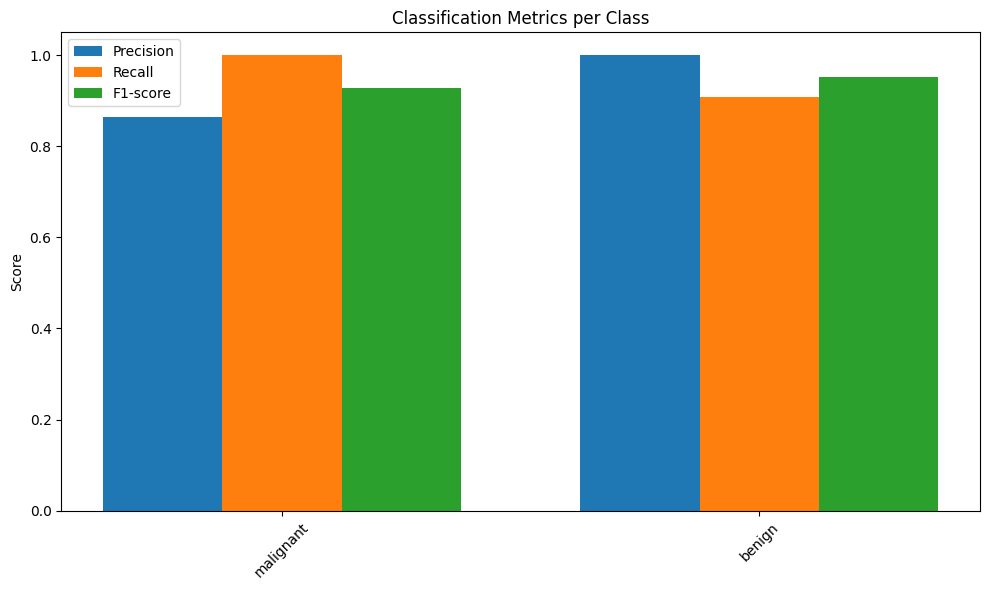

In [7]:
# Metrics per class in a table and a bar diagram
precision_per_class = precision_score(y_test, y_pred_test, average=None)
recall_per_class = recall_score(y_test, y_pred_test, average=None)
f1_per_class = f1_score(y_test, y_pred_test, average=None)

# Convert to DataFrame for table display
metrics_df = pd.DataFrame({
    'Class': target_names,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-score': f1_per_class
})

print("\nMetrics per class:")
print(metrics_df.to_string(index=False))

# Plot
x = np.arange(len(target_names))
width = 0.25

plt.figure(figsize=(10,6))
plt.bar(x - width, precision_per_class, width, label='Precision')
plt.bar(x, recall_per_class, width, label='Recall')
plt.bar(x + width, f1_per_class, width, label='F1-score')
plt.xticks(x, target_names, rotation=45)
plt.ylabel("Score")
plt.title("Classification Metrics per Class")
plt.legend()
plt.tight_layout()
plt.show()

#### **Confusion Matrix:** Detailed analysis of classification errors
- This code generates a confusion matrix for the model’s predictions on the test set using the best maximum depth and minimum samples split 
- It visualizes it with a color-coded heatmap.

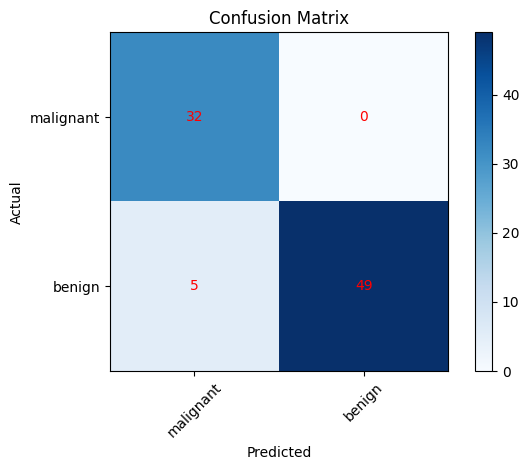

In [8]:
cm = confusion_matrix(y_test, y_pred_test)
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(np.arange(len(target_names)), target_names, rotation=45)
plt.yticks(np.arange(len(target_names)), target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
# Annotate counts in the confusion matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="red")
plt.tight_layout()
plt.show()

#### **Tree Complexity:** Analyzing the relationship between tree depth and performance
- This section analyzes how the tree depth affects the classifier's performance and overfitting behavior.
- We train several decision trees with different max_depth values (while keeping min_samples_split fixed as the best min_samples_split) and evaluate:
  - Training accuracy
  - Validation accuracy
  - Overfitting gap (Train − Validation accuracy)
  - Tree size (number of nodes)
  
- Analyzing the tree depth vs **validation and training accuracy** lets us determine the following:
  - small depth --> model underfits and is too simple with high bias
  - very large depth --> model overfits as it memorizes training data with high variance
  - We are seeking the depth that gives high validation accuracy without a large overfitting gap.
  - overfitting gap = training accuracy - validation accuracy

- Analyzing the tree depth vs **number of nodes**
  - at first, number of nodes grows exponentially

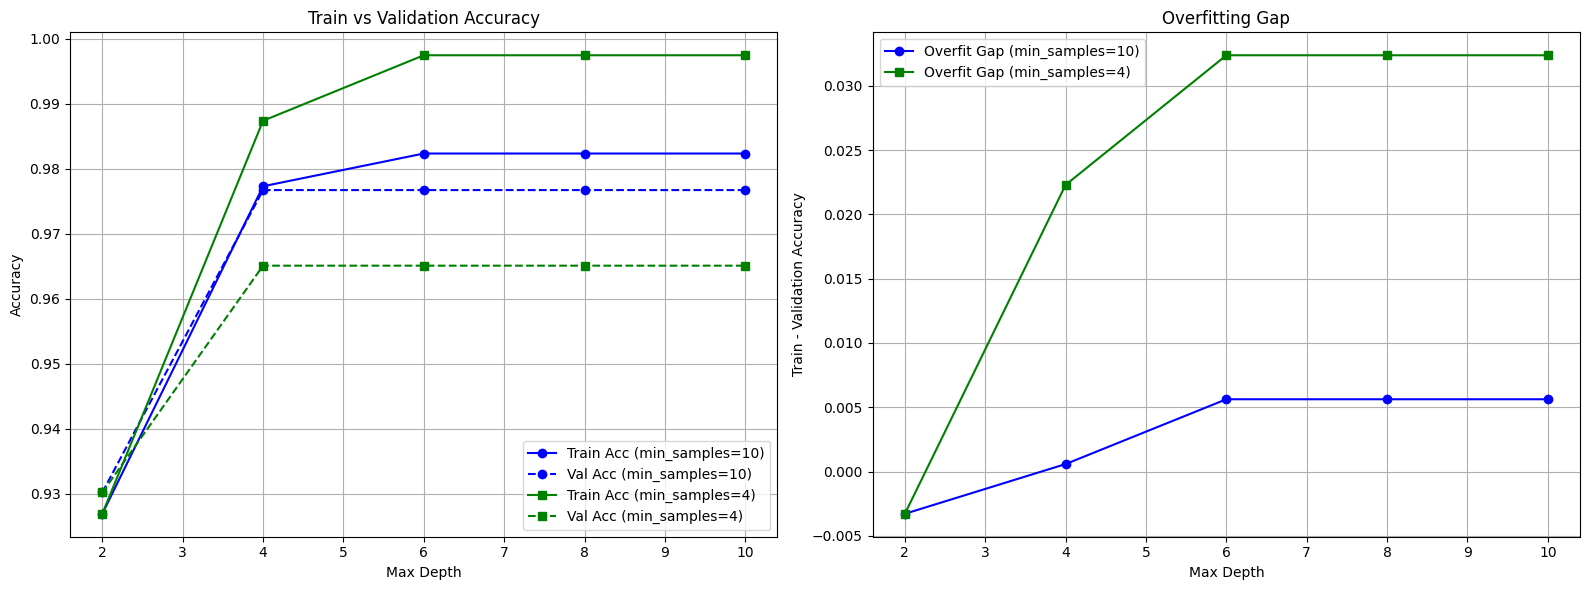

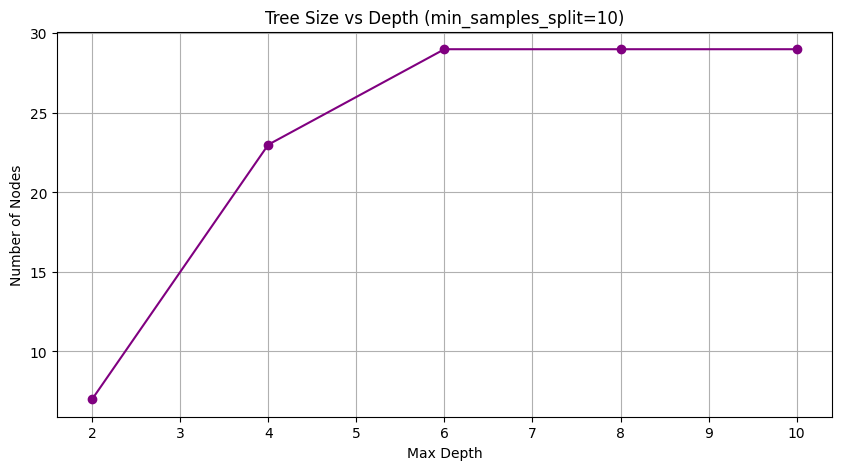

In [9]:
# Training vs validation accuracy for varying max_depth (min_samples_split fixed)
results = {}

train_accs, val_accs, num_nodes = [], [], []
min_samples_list = [best_min_samples, 4]

for min_s in min_samples_list:
    train_accs, val_accs, num_nodes = [], [], []

    for depth in max_depth_values:
        tree = DecisionTreeClassifier(max_depth=depth, min_samples_split=min_s)
        tree.fit(X_train, y_train)

        train_accs.append(accuracy_score(y_train, tree.predict(X_train)))
        val_accs.append(accuracy_score(y_val, tree.predict(X_val)))
        num_nodes.append(count_nodes(tree.root))  # make sure count_nodes works

    # store results for plotting
    results[min_s] = {
        'train_accs': train_accs,
        'val_accs': val_accs,
        'num_nodes': num_nodes,
        'overfit_gap': np.array(train_accs) - np.array(val_accs)
    }
    
colors = ['blue', 'green']
markers = ['o', 's']

fig, axes = plt.subplots(1, 2, figsize=(16,6))

# --- Left Plot: Train vs Validation Accuracy ---
for idx, min_s in enumerate(min_samples_list):
    axes[0].plot(max_depth_values, results[min_s]['train_accs'],
                 marker=markers[idx], color=colors[idx], linestyle='-',
                 label=f'Train Acc (min_samples={min_s})')
    axes[0].plot(max_depth_values, results[min_s]['val_accs'],
                 marker=markers[idx], color=colors[idx], linestyle='--',
                 label=f'Val Acc (min_samples={min_s})')

axes[0].set_xlabel('Max Depth')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Train vs Validation Accuracy')
axes[0].legend()
axes[0].grid(True)

# --- Right Plot: Overfitting Gap ---
for idx, min_s in enumerate(min_samples_list):
    axes[1].plot(max_depth_values, results[min_s]['overfit_gap'],
                 marker=markers[idx], color=colors[idx],
                 label=f'Overfit Gap (min_samples={min_s})')

axes[1].set_xlabel('Max Depth')
axes[1].set_ylabel('Train - Validation Accuracy')
axes[1].set_title('Overfitting Gap')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Plotting Tree size (Number of nodes) vs depth 
plt.figure(figsize=(10,5)) 
plt.plot(max_depth_values, num_nodes, marker='o', color='purple') 
plt.xlabel('Max Depth') 
plt.ylabel('Number of Nodes') 
plt.title(f'Tree Size vs Depth (min_samples_split={best_min_samples})') 
plt.grid(True) 
plt.show()

#### **Features Importance:** Ranking Features by their information gain contribution
- Accumulating the Importance of each feature is calculated by weighing the information gain depending on the number of samples at that node.
- This ensures that splits at the top of the tree have a higher importancy because they influence more samples
- We then convert raw scores into a probability distribution, making all importances sum to 1.0
- A high score means the feature:  
  - appeared in many important splits or  
  - produced splits with high information gain  
  - influenced a large portion of the tree (if weighted by sample count)  
- A score of zero means:  
  - the feature was never used for a split.

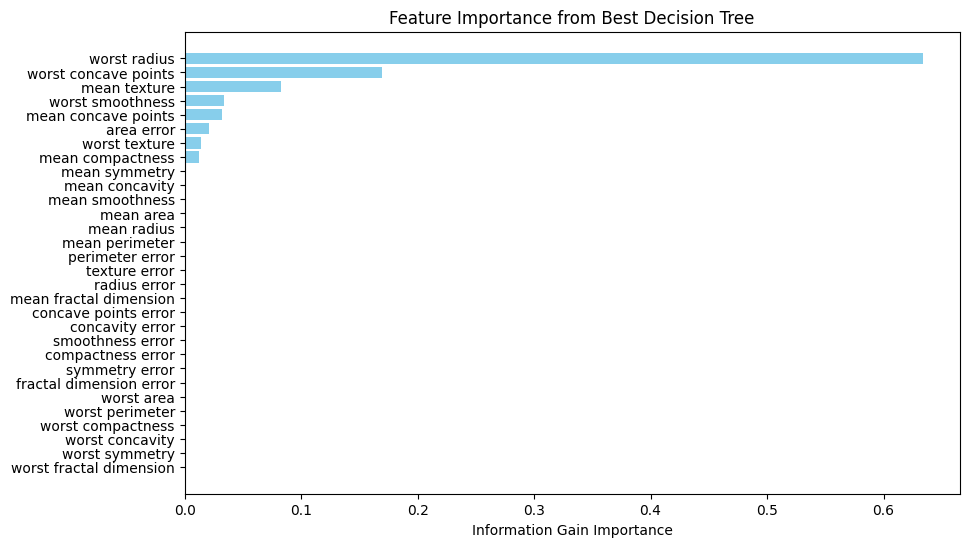

In [10]:
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_tree.feature_importances_
}).sort_values('Importance', ascending=False)


plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel("Information Gain Importance")
plt.title("Feature Importance from Best Decision Tree")
plt.gca().invert_yaxis()
plt.show()